<a href="https://colab.research.google.com/github/annabarsukovaca-stack/Machine-Learning-Practice/blob/main/Ch_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

New terminology

Root - First/top question
Node - A question/split
Leaf - Final prediction; no more questions
Depth - How far down the tree
Split - Dividing data into groups
Threshold - The value used for a split
Gini impurity	- How mixed the classes are
Pure node	- Contains only one class
max_depth	- Maximum tree depth
Overfitting	- Tree becomes too complicated and memorizes training data

In [1]:
import sys
assert sys.version_info >= (3, 5)

import sklearn
assert sklearn.__version__ >= "0.20"

import numpy as np
import os

# To make notebook output stable across runs
np.random.seed(42)

# To plot figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

training a decision tree classifier

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()

X = iris.data[:, 2:]  # petal length and petal width
y = iris.target

tree_clf = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

X = input features; here, petal length and width.

y = target classes.

DecisionTreeClassifier predicts categories/classes.

max_depth=2 limits how deep the tree can grow.

.fit(X, y) trains the model.

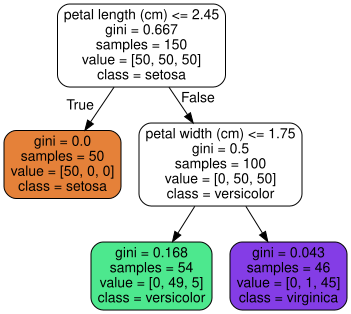

In [3]:
from sklearn.tree import export_graphviz
from graphviz import Source

export_graphviz(
    tree_clf,
    out_file=os.path.join(IMAGES_PATH, "iris_tree.dot"),
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

Source.from_file(
    os.path.join(IMAGES_PATH, "iris_tree.dot")
)

export_graphviz() converts the trained tree into a visual description.

feature_names gives the feature names.

class_names gives the class names.

This helps to see the tree's questions, thresholds, Gini values, samples, and predictions

In [4]:
tree_clf.predict([[5, 1.5]])

array([1])

Gives the predicted class for a flower with:
petal length = 5
petal width = 1.5

The tree follows its decision rules from the root to a leaf

In [5]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

Returns the probability of each class.

Here:
Setosa = 0%
Versicolor = 90.7%
Virginica = 9.3%

Probabilities come from the class proportions in the final leaf

In [6]:
print("Probabilities:", tree_clf.predict_proba([[5, 1.5]]))
print("Prediction:", tree_clf.predict([[5, 1.5]]))

Probabilities: [[0.         0.90740741 0.09259259]]
Prediction: [1]


predict_proba() tells how likely each class is

predict() chooses the class with the highest probability.

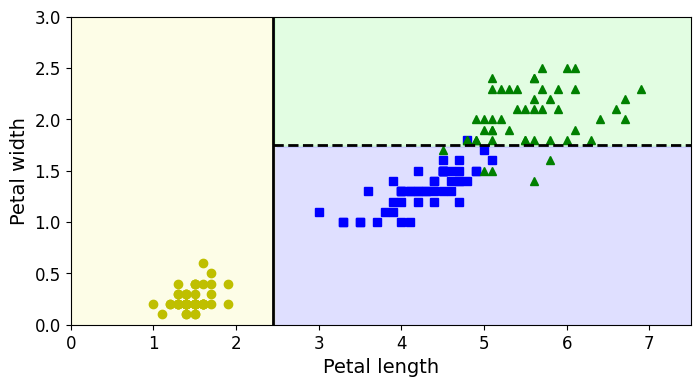

In [7]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(
    clf,
    X,
    y,
    axes=[0, 7.5, 0, 3],
    iris=True,
    legend=False,
    plot_training=True
):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)

    x1, x2 = np.meshgrid(x1s, x2s)

    X_new = np.c_[x1.ravel(), x2.ravel()]

    y_pred = clf.predict(X_new).reshape(x1.shape)

    custom_cmap = ListedColormap(
        ['#fafab0', '#9898ff', '#a0faa0']
    )

    plt.contourf(
        x1,
        x2,
        y_pred,
        alpha=0.3,
        cmap=custom_cmap
    )

    if plot_training:
        plt.plot(
            X[:, 0][y == 0],
            X[:, 1][y == 0],
            "yo",
            label="Iris setosa"
        )

        plt.plot(
            X[:, 0][y == 1],
            X[:, 1][y == 1],
            "bs",
            label="Iris versicolor"
        )

        plt.plot(
            X[:, 0][y == 2],
            X[:, 1][y == 2],
            "g^",
            label="Iris virginica"
        )

        plt.axis(axes)

    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)

    if legend:
        plt.legend(loc="lower right", fontsize=14)


plt.figure(figsize=(8, 4))

plot_decision_boundary(
    tree_clf,
    X,
    y
)

plt.plot(
    [2.45, 2.45],
    [0, 3],
    "k-",
    linewidth=2
)

plt.plot(
    [2.45, 7.5],
    [1.75, 1.75],
    "k--",
    linewidth=2
)

plt.show()

this shows the regions where the tree predicts different classes; the vertical line represents a rule (such as petal lenght is less/equal to 2.45).

Decision Trees create step-like/ rectangular decision boundaries

In [8]:
tree_clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_clf.fit(X, y)

print(tree_clf.predict([[5, 1.5]]))

[2]


max–depth allows the tree to make more decisions. More depth means more complex model. Too much depth means higher rrisk of overfitting

In [9]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=2,
    random_state=42
)

tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=42
)

tree_gini.fit(X, y)
tree_entropy.fit(X, y)

print("Gini prediction:", tree_gini.predict([[5, 1.5]]))
print("Entropy prediction:", tree_entropy.predict([[5, 1.5]]))

Gini prediction: [1]
Entropy prediction: [1]


gini = default impurity measure
entropy = alternative impurity measure

so, both measure how mixed a node is, results are similar, but gini is a bit faster

In [10]:
p = np.array([0, 49/54, 5/54])

gini = 1 - np.sum(p ** 2)

print(gini)

0.16803840877914955


if gini = 0 means the node is completely pure, higher Gini - more mixed classes

In [11]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(
    n_samples=100,
    noise=0.25,
    random_state=53
)

print(Xm.shape)
print(ym.shape)

(100, 2)
(100,)


make_moons() creates an artificial classification dataset
noise makes the dataset more difficult

this dataset is useful for demonstrating overfitting and regularization

In [12]:
from sklearn.tree import DecisionTreeClassifier

deep_tree_clf1 = DecisionTreeClassifier(
    random_state=42
)

deep_tree_clf1.fit(Xm, ym)

DecisionTreeClassifier(random_state=42)

unrestricted decision tree

In [13]:
deep_tree_clf2 = DecisionTreeClassifier(
    min_samples_leaf=4,
    random_state=42
)

deep_tree_clf2.fit(Xm, ym)

DecisionTreeClassifier(min_samples_leaf=4, random_state=42)

every leaf must contain at least 4 training examples. More restrictions - simpler tree, less overfitting

In [14]:
prediction1 = deep_tree_clf1.predict([[0, 0]])
prediction2 = deep_tree_clf2.predict([[0, 0]])

print("Unrestricted tree:", prediction1)
print("Regularized tree:", prediction2)

Unrestricted tree: [1]
Regularized tree: [1]


compare predictions. both models make predictions, but their complexity differs

In [15]:
tree_clf_1 = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_clf_2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=40
)

tree_clf_1.fit(X, y)
tree_clf_2.fit(X, y)

print(tree_clf_1.predict([[5, 1.5]]))
print(tree_clf_2.predict([[5, 1.5]]))

[1]
[1]


changing random_state can change the trained tree. Decision Trees can be unstable

random_state makes experiments reproducible

In [16]:
angle = np.pi / 180 * 20

rotation_matrix = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle), np.cos(angle)]
])

Xr = X.dot(rotation_matrix)

tree_clf_r = DecisionTreeClassifier(
    random_state=42
)

tree_clf_r.fit(Xr, y)

DecisionTreeClassifier(random_state=42)

demonstrate rotation sensitivity
rotates the dataset
Decision Trees prefer axis-aligned boundaries

In [17]:
np.random.seed(42)

m = 200

X = np.random.rand(m, 1)

y = 4 * (X - 0.5) ** 2

y = y + np.random.randn(m, 1) / 10

create regression dataset
X - input
y - numerical target

In [18]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(
    max_depth=2,
    random_state=42
)

tree_reg.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=42)

training a Decision Tree Regressor

DecisionTreeRegressor predicts numerical values

max_depth=2 limits complexity

In [19]:
prediction = tree_reg.predict([[0.6]])

print(prediction)

[0.11063973]


The prediction is the average target value of the training samples in that leaf

In [20]:
tree_reg1 = DecisionTreeRegressor(
    max_depth=2,
    random_state=42
)

tree_reg2 = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

print("Depth 2:", tree_reg1.predict([[0.6]]))
print("Depth 3:", tree_reg2.predict([[0.6]]))

Depth 2: [0.11063973]
Depth 3: [0.08445536]


Depth 3 can create more detailed predictions than depth 2

more depth can fit the training data more closely

Too much depth - overfitting

In [21]:
tree_reg1 = DecisionTreeRegressor(
    random_state=42
)

tree_reg2 = DecisionTreeRegressor(
    min_samples_leaf=10,
    random_state=42
)

tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

DecisionTreeRegressor(min_samples_leaf=10, random_state=42)

min_samples_leaf=10 reduces overfitting

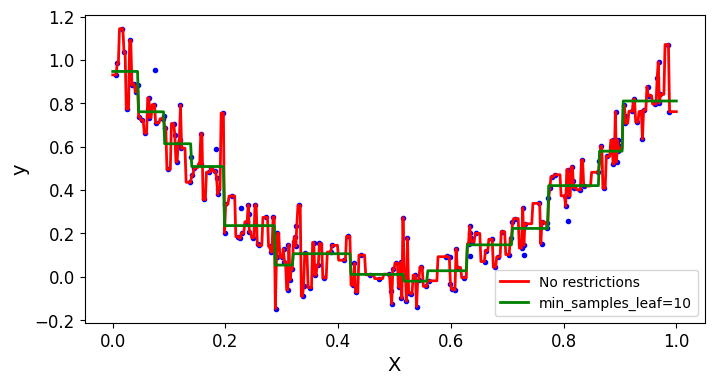

In [22]:
x1 = np.linspace(0, 1, 500).reshape(-1, 1)

y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

plt.figure(figsize=(8, 4))

plt.plot(X, y, "b.")
plt.plot(
    x1,
    y_pred1,
    "r-",
    linewidth=2,
    label="No restrictions"
)

plt.plot(
    x1,
    y_pred2,
    "g-",
    linewidth=2,
    label="min_samples_leaf=10"
)

plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

regression predictions visualization

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ML code
splits data into 80% training data and 20% test data

In [24]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=10000,
    noise=0.4,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

creates 10,000 artificial examples

adds noise to make classification harder

keeps 20% as unseen test data

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_leaf_nodes": list(range(2, 100)),
    "min_samples_split": [2, 3, 4]
}

grid_search_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    verbose=1,
    cv=3
)

grid_search_cv.fit(X_train, y_train)

Fitting 3 folds for each of 294 candidates, totalling 882 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]},
             verbose=1)

Tests many hyperparameter combinations automatically.
cv=3 means 3-fold cross-validation.
max_leaf_nodes controls tree size.
min_samples_split controls when splitting is allowed.
This is called hyperparameter tuning.

In [26]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_leaf_nodes=17, random_state=42)

find the best model

In [27]:
from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)

accuracy_score(y_test, y_pred)

0.8695

evaluate the best model

In [28]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

rs = ShuffleSplit(
    n_splits=n_trees,
    test_size=len(X_train) - n_instances,
    random_state=42
)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]

    mini_sets.append(
        (X_mini_train, y_mini_train)
    )

create 1,000 random training subsets, each consists of 100 training examples

In [29]:
from sklearn.base import clone

forest = [
    clone(grid_search_cv.best_estimator_)
    for _ in range(n_trees)
]

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(
    forest,
    mini_sets
):
    tree.fit(
        X_mini_train,
        y_mini_train
    )

    y_pred = tree.predict(X_test)

    accuracy_scores.append(
        accuracy_score(y_test, y_pred)
    )

np.mean(accuracy_scores)

np.float64(0.805471)

create 1,000 decision trees
average indiv capacity is about 80.5%

In [30]:
Y_pred = np.empty(
    [n_trees, len(X_test)],
    dtype=np.uint8
)

for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

collect predictions from all trees

In [31]:
from scipy.stats import mode

y_pred_majority_votes, n_votes = mode(
    Y_pred,
    axis=0
)

chooses the prediction that appears most often

In [32]:
accuracy_score(
    y_test,
    y_pred_majority_votes.reshape([-1])
)

0.872

Combined accuracy ≈ 87.2%.
The individual trees averaged about 80.5%.
Combining many trees makes the prediction more stable.